<a href="https://colab.research.google.com/github/aryasubash/Ride-Hailing-Demand-and-Pricing-Analysis/blob/main/Ridesharingdataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Understanding and Cleaning

In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

df=pd.read_csv("/content/rideshare_kaggle.csv")

print("Rows and Columns:", df.shape)
print(df.head())
print(df.info())


Rows and Columns: (693071, 57)
                                     id     timestamp  hour  day  month  \
0  424553bb-7174-41ea-aeb4-fe06d4f4b9d7  1.544953e+09     9   16     12   
1  4bd23055-6827-41c6-b23b-3c491f24e74d  1.543284e+09     2   27     11   
2  981a3613-77af-4620-a42a-0c0866077d1e  1.543367e+09     1   28     11   
3  c2d88af2-d278-4bfd-a8d0-29ca77cc5512  1.543554e+09     4   30     11   
4  e0126e1f-8ca9-4f2e-82b3-50505a09db9a  1.543463e+09     3   29     11   

              datetime          timezone            source    destination  \
0  2018-12-16 09:30:07  America/New_York  Haymarket Square  North Station   
1  2018-11-27 02:00:23  America/New_York  Haymarket Square  North Station   
2  2018-11-28 01:00:22  America/New_York  Haymarket Square  North Station   
3  2018-11-30 04:53:02  America/New_York  Haymarket Square  North Station   
4  2018-11-29 03:49:20  America/New_York  Haymarket Square  North Station   

  cab_type  ... precipIntensityMax uvIndexTime  tempera

In [5]:
missing = df.isnull().sum()
print(missing[missing > 0])

#Makes the columns easier to use in Python.
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
df = df.dropna(subset=['price'])


# Remove duplicate rows if any exist.
df = df.drop_duplicates()
print(df.shape)


price    55095
dtype: int64
(637976, 57)


Feature engineering for Big Data Analytics
1. Datetime into day of the week colum
2. Timeperiod into time of the day (morning, afternoon, evening and night )
3. Day feature into weekend and weekday categorisation. (Beneficial for BI plots)
4. Distance transformed into a category feature with short, medium, long and very long.


In [ ]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day_name()

print(df.head())

                                     id     timestamp  hour        day  month  \
0  424553bb-7174-41ea-aeb4-fe06d4f4b9d7  1.544953e+09     9     Sunday     12   
1  4bd23055-6827-41c6-b23b-3c491f24e74d  1.543284e+09     2    Tuesday     11   
2  981a3613-77af-4620-a42a-0c0866077d1e  1.543367e+09     1  Wednesday     11   
3  c2d88af2-d278-4bfd-a8d0-29ca77cc5512  1.543554e+09     4     Friday     11   
4  e0126e1f-8ca9-4f2e-82b3-50505a09db9a  1.543463e+09     3   Thursday     11   

                       datetime          timezone            source  \
0 2018-12-16 09:30:07.890000105  America/New_York  Haymarket Square   
1 2018-11-27 02:00:23.677000046  America/New_York  Haymarket Square   
2 2018-11-28 01:00:22.197999954  America/New_York  Haymarket Square   
3 2018-11-30 04:53:02.749000072  America/New_York  Haymarket Square   
4 2018-11-29 03:49:20.223000050  America/New_York  Haymarket Square   

     destination cab_type  ... precipintensitymax uvindextime  temperaturemin  \
0  No

In [7]:
# Time of the day categorised colum creation.
def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_period"] = df["hour"].apply(time_period)


# The precreated day column is been used to categorise the ride into weekday or weekend.
df["is_weekend"] = df["day"].isin(["Saturday", "Sunday"])

df["day_type"] = df["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

# The distance column can be tranformed into 4 categories accoring to the distance travelled.
df["distance_category"] = pd.cut(
    df["distance"],
    bins=[0,2,5,10,20],
    labels=[
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

print(df.head())







                                     id     timestamp  hour        day  month  \
0  424553bb-7174-41ea-aeb4-fe06d4f4b9d7  1.544953e+09     9     Sunday     12   
1  4bd23055-6827-41c6-b23b-3c491f24e74d  1.543284e+09     2    Tuesday     11   
2  981a3613-77af-4620-a42a-0c0866077d1e  1.543367e+09     1  Wednesday     11   
3  c2d88af2-d278-4bfd-a8d0-29ca77cc5512  1.543554e+09     4     Friday     11   
4  e0126e1f-8ca9-4f2e-82b3-50505a09db9a  1.543463e+09     3   Thursday     11   

                       datetime          timezone            source  \
0 2018-12-16 09:30:07.890000105  America/New_York  Haymarket Square   
1 2018-11-27 02:00:23.677000046  America/New_York  Haymarket Square   
2 2018-11-28 01:00:22.197999954  America/New_York  Haymarket Square   
3 2018-11-30 04:53:02.749000072  America/New_York  Haymarket Square   
4 2018-11-29 03:49:20.223000050  America/New_York  Haymarket Square   

     destination cab_type  ... temperaturemax temperaturemaxtime  \
0  North Station  

Correlation Analysis :
Using python analyis to determine if travel fare seem to increase with the distance.  

In [8]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

price_corr = corr_matrix['price'].sort_values(ascending=False)

print("Correlation of variables with Price:\n")
print(price_corr)

Correlation of variables with Price:

price                          1.000000
distance                       0.345061
surge_multiplier               0.240458
latitude                       0.002088
visibility                     0.001497
visibility.1                   0.001497
windgust                       0.001218
precipintensitymax             0.001114
windspeed                      0.000990
month                          0.000913
cloudcover                     0.000883
pressure                       0.000866
windgusttime                   0.000851
apparenttemperaturelow         0.000831
apparenttemperaturemintime     0.000814
timestamp                      0.000808
temperaturemintime             0.000769
temperaturemaxtime             0.000766
uvindextime                    0.000763
apparenttemperaturelowtime     0.000761
sunsettime                     0.000760
sunrisetime                    0.000760
temperaturehightime            0.000759
temperaturelowtime             0.000754
ap

Exploritary Data Analsysis (EDA)
Main expectations:
1. To find Demand by time period, Demand on Weekend vs Weekday
2. Price distribution by Distance category
3. Weather effect on ride frequency

These visualisations has been created for the basic understanding of the data and not for dashboards.

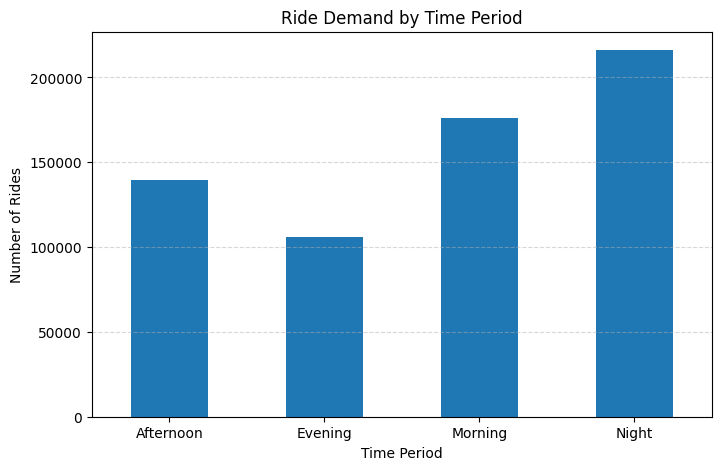

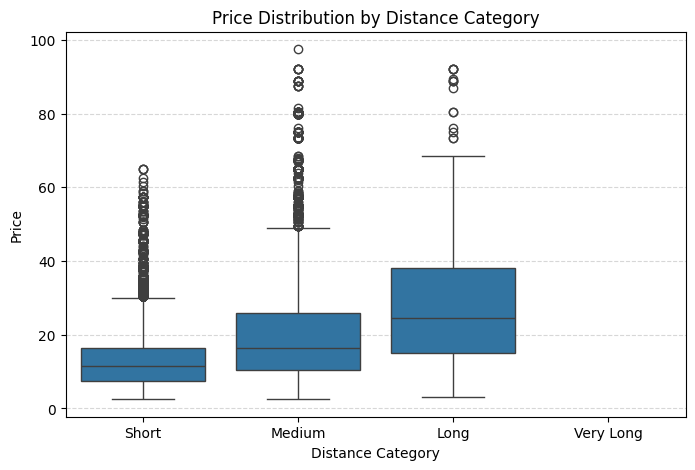

In [9]:
# Demand bt time period of the day
plt.figure(figsize=(8,5))

df.groupby('time_period')['time_period'].count().plot(kind='bar')

plt.xlabel('Time Period')
plt.ylabel('Number of Rides')
plt.title('Ride Demand by Time Period')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


#Price distribution by Distance category
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='distance_category',
    y='price'
)

plt.xlabel('Distance Category')
plt.ylabel('Price')
plt.title('Price Distribution by Distance Category')

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Exporting the cleaned dataset for further visualisations in Microsoft Power BI.

In [11]:
df.to_csv("cleaned_rideshare_dataset.csv", index=False)